In [1]:
!pip -q install -U transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.7 MB/s eta 0:00:00


In [23]:
#Libraries
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
import matplotlib.pyplot as plt
from transformers import set_seed
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
#Setup reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB


In [7]:
#Load the dataset
train_df = pd.read_csv("/content/phishing_train.csv")
val_df = pd.read_csv("/content/phishing_validation.csv")
test_df = pd.read_csv("/content/phishing_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)


In [9]:
#Convert dataset
train_dataset = Dataset.from_pandas(
    train_df[["processed_text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["processed_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["processed_text", "label"]],
    preserve_index=False
)

In [11]:
#Load ModernBert-large
MODEL_NAME = "answerdotai/ModernBERT-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenizer loaded: answerdotai/ModernBERT-large


In [12]:
#Tokenize
MAX_LENGTH = 8192

def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)
print(train_tokenized)

Map:   0%|          | 0/14015 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 14015
})


In [14]:
#Load the model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

print("Model dtype:", next(model.parameters()).dtype)
print("ModernBERT-large loaded.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.58GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dtype: torch.float32
ModernBERT-large loaded.


In [16]:
#Evaluation metrix
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [18]:
#Setup configure
training_args = TrainingArguments(
    output_dir="/content/modernbert_large_results",

    num_train_epochs=3,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=16,

    learning_rate=1e-5,
    weight_decay=0.01,

    warmup_steps=263,
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,
      load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=False,
    bf16=False,

    optim="adamw_torch",

    seed=42,
    data_seed=42,

    report_to="none",
    save_total_limit=2
)

In [19]:
#Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("ModernBERT-large Trainer ready.")

ModernBERT-large Trainer ready.


In [20]:
#Train the model
train_result = trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.350811,0.130079,0.983447,0.961595,0.995413,0.978212
2,0.347073,0.087836,0.988014,0.977376,0.990826,0.984055
3,0.059268,0.065411,0.993721,0.990840,0.992355,0.991597


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
#Evaluate test set
test_results = trainer.evaluate(
    test_tokenized,
    metric_key_prefix="test"
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.059268,0.062259,3,0.993721,0.989346,0.993884,0.991609


{'test_loss': 0.06225944682955742, 'test_accuracy': 0.9937214611872146, 'test_precision': 0.989345509893455, 'test_recall': 0.9938837920489296, 'test_f1': 0.9916094584286804}


                precision    recall  f1-score   support

    Safe Email     0.9963    0.9936    0.9950      1098
Phishing Email     0.9893    0.9939    0.9916       654

      accuracy                         0.9937      1752
     macro avg     0.9928    0.9938    0.9933      1752
  weighted avg     0.9937    0.9937    0.9937      1752

Confusion Matrix:
[[1091    7]
 [   4  650]]


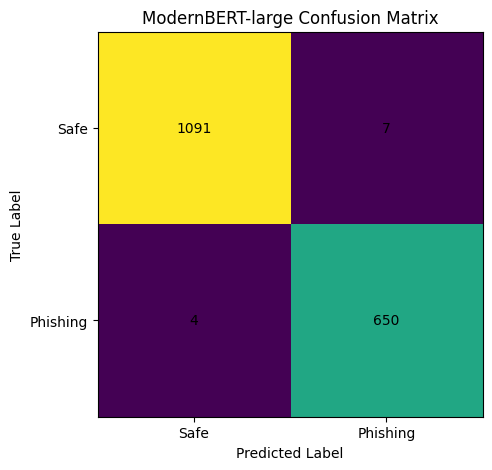

In [24]:
#Confusion metrix
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe Email", "Phishing Email"],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("ModernBERT-large Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Safe", "Phishing"])
plt.yticks([0, 1], ["Safe", "Phishing"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()